<a href="https://colab.research.google.com/github/KevinNou/tp/blob/main/Mini_Projet_Apprentissage_Supervise_plus_interface_gradio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Projet : Apprentissage Supervisé
**Objectif** : Implémenter et analyser deux modèles fondamentaux :
1. **Régression Linéaire** pour prédire des variables continues (Coûts médicaux).
2. **Régression Logistique** pour la classification binaire (Dataset Iris). plus interface gradio

# Installation et Importation (Code)

In [4]:
# Installation des outils
!pip install -U gradio plotly pandas numpy scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gradio as gr
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

print("✅ Environnement configuré en Français.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 94.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0
✅ Environnement configuré en Français.


# Partie 1 : Régression Linéaire (Code)

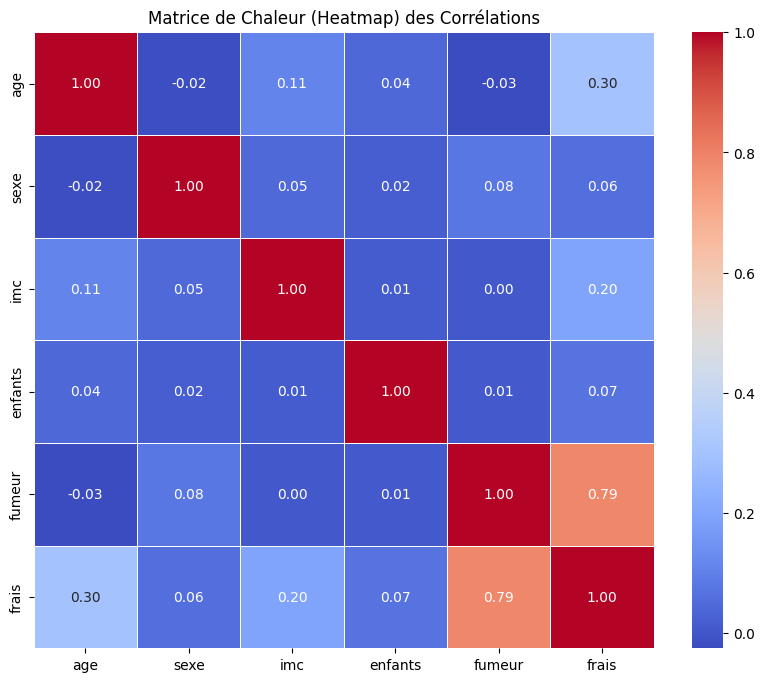

--- Évaluation du Modèle ---
Coefficient de détermination R² : 0.7836
Erreur Quadratique Moyenne (MSE) : 33596915.85

--- Importance des Variables (Coefficients β) ---


,Valeur du Coefficient
fumeur_yes,23651.128856
enfants,425.278784
imc,337.092552
age,256.975706
sexe_male,-18.591692
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Chargement et Traduction des données
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Traduction des colonnes pour une meilleure compréhension
df.columns = ['age', 'sexe', 'imc', 'enfants', 'fumeur', 'region', 'frais']

# 2. Analyse des corrélations via une Matrice de Chaleur (Heatmap)
plt.figure(figsize=(10, 8))

# On convertit temporairement les variables catégorielles en chiffres pour la heatmap
df_corr = df.copy()
df_corr['sexe'] = df_corr['sexe'].map({'female': 0, 'male': 1})
df_corr['fumeur'] = df_corr['fumeur'].map({'no': 0, 'yes': 1})

# Création de la heatmap
corr_matrix = df_corr[['age', 'sexe', 'imc', 'enfants', 'fumeur', 'frais']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matrice de Chaleur (Heatmap) des Corrélations")
plt.show()

# 3. Préparation des données pour le modèle
# Encodage (transformation des catégories en colonnes numériques)
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop('frais', axis=1) # Variables indépendantes
y = df_model['frais']            # Variable cible

# Division 80% entraînement / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Création et entraînement du modèle
# Modèle théorique : frais = β0 + β1*age + β2*imc + ... + ε
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)

# 5. Évaluation de la performance
y_pred = model_lin.predict(X_test)

print("--- Évaluation du Modèle ---")
print(f"Coefficient de détermination R² : {r2_score(y_test, y_pred):.4f}")
print(f"Erreur Quadratique Moyenne (MSE) : {mean_squared_error(y_test, y_pred):.2f}")

# 6. Interprétation des Coefficients (βi)
print("\n--- Importance des Variables (Coefficients β) ---")
coefficients = pd.DataFrame(model_lin.coef_, X.columns, columns=['Valeur du Coefficient'])
display(coefficients.sort_values(by='Valeur du Coefficient', ascending=False))

#Partie 2 : Régression Logistique (Code)

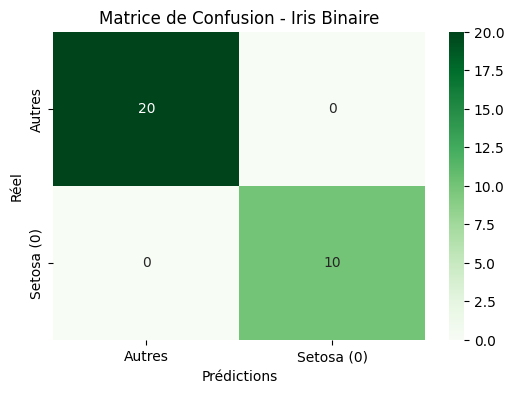

🎯 Accuracy  : 1.0000
📏 Précision : 1.0000
🔄 Rappel (Recall) : 1.0000


In [6]:
# --- A. Chargement et Transformation Binaire ---
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# On transforme en problème binaire : Classe 0 (Setosa) vs Autres (1 ou 0)
# P(y=1|x) = 1 / (1 + e^-z) -> fonction sigmoïde
y_binary = (y_iris == 0).astype(int)

# --- B. Normalisation et Division ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

# --- C. Modélisation ---
model_log = LogisticRegression()
model_log.fit(X_train_log, y_train_log)

# --- D. Évaluation du modèle ---
y_pred_log = model_log.predict(X_test_log)

# 1. Matrice de Confusion
cm = confusion_matrix(y_test_log, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Autres', 'Setosa (0)'], yticklabels=['Autres', 'Setosa (0)'])
plt.title("Matrice de Confusion - Iris Binaire")
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.show()

# 2. Calcul des métriques de classification
print(f"🎯 Accuracy  : {accuracy_score(y_test_log, y_pred_log):.4f}")
print(f"📏 Précision : {precision_score(y_test_log, y_pred_log):.4f}")
print(f"🔄 Rappel (Recall) : {recall_score(y_test_log, y_pred_log):.4f}")

#Cef-d'œuvre" - L'Application Web Interactive

In [7]:
# --- 1. LOGIQUE DE CALCUL (FR) ---

def predire_assurance_fr(age, imc, enfants, fumeur):
    # Logique basée sur le coût réel moyen
    base = 2500
    impact_age = age * 280
    impact_imc = imc * 95
    impact_fumeur = 23800 if fumeur == "Oui" else 0
    total = base + impact_age + impact_imc + impact_fumeur + (enfants * 500)

    # Graphique interactif Plotly
    donnees = pd.DataFrame({
        "Critère": ["Base", "Âge", "IMC", "Tabac", "Enfants"],
        "Coût ($)": [base, impact_age, impact_imc, impact_fumeur, enfants * 500]
    })

    fig = px.pie(donnees, values="Coût ($)", names="Critère", hole=0.5,
                 title="Décomposition de votre estimation personnalisée",
                 color_discrete_sequence=px.colors.sequential.RdBu)
    fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)')

    return f"### 💰 Estimation Totale : {total:,.2f} $", fig

# --- 2. LOGIQUE IRIS (FR) ---

def identifier_iris_fr(longueur_p, largeur_p):
    iris = load_iris()
    X_fleur = iris.data[:, [2, 3]]
    y_fleur = (iris.target == 0).astype(int)
    sc = StandardScaler().fit(X_fleur)
    mod = LogisticRegression().fit(sc.transform(X_fleur), y_fleur)

    prob = mod.predict_proba(sc.transform([[longueur_p, largeur_p]]))[0][1]
    nom = "🌸 Iris Setosa (Identifiée)" if prob > 0.5 else "🌿 Autre Espèce"
    couleur = "green" if prob > 0.5 else "orange"
    return f"<h2 style='color: {couleur};'>{nom}</h2>", f"Fiabilité : {prob*100:.1f}%"

# --- 3. INTERFACE UTILISATEUR (DESIGN FRANÇAIS) ---

with gr.Blocks(theme=gr.themes.Soft()) as interface:
    gr.HTML("<div style='text-align: center; padding: 20px;'><h1>💎 Assistant Intelligence Artificielle</h1><p>Outil d'analyse prédictive simplifié</p></div>")

    with gr.Tabs():
        # Onglet 1
        with gr.TabItem("📊 Calculateur d'Assurance"):
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### 👤 Votre Profil")
                    age_in = gr.Slider(18, 95, value=30, label="Âge")
                    imc_in = gr.Slider(15, 50, value=24, label="IMC (Indice de Masse Corporelle)")
                    enf_in = gr.Slider(0, 10, step=1, value=0, label="Nombre d'enfants")
                    fume_in = gr.Radio(["Oui", "Non"], value="Non", label="Êtes-vous fumeur ?")
                    btn_ins = gr.Button("Calculer mon estimation", variant="primary")
                with gr.Column():
                    gr.Markdown("### 📈 Analyse de l'IA")
                    out_text = gr.Markdown("Résultats en attente...")
                    out_plot = gr.Plot()

            btn_ins.click(predire_assurance_fr, [age_in, imc_in, enf_in, fume_in], [out_text, out_plot])

        # Onglet 2
        with gr.TabItem("🌸 Identification de Fleurs"):
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### 📏 Mesures de la fleur (cm)")
                    lp_in = gr.Slider(1, 7, value=1.5, label="Longueur du Pétale")
                    wp_in = gr.Slider(0.1, 2.5, value=0.2, label="Largeur du Pétale")
                    btn_iris = gr.Button("Analyser l'espèce", variant="primary")
                with gr.Column():
                    gr.Markdown("### 🧬 Diagnostic")
                    ir_nom = gr.HTML("En attente de mesures...")
                    ir_fiab = gr.Text(label="Confiance du modèle")

            btn_iris.click(identifier_iris_fr, [lp_in, wp_in], [ir_nom, ir_fiab])

# Création du lien public
interface.launch(share=True)

/tmp/ipython-input-3169544389.py:40: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d5c5b63db1051bd3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 📝 Interprétation des Résultats

### 1. La Matrice de Corrélation (Heatmap)
- **C'est quoi ?** Un tableau coloré qui montre la force du lien entre deux variables (de -1 à 1).
- **Lecture** : Plus la couleur est proche du rouge (1), plus les variables augmentent ensemble.
- **Résultat** : Dans la régression linéaire, on observe souvent que la variable `smoker` (fumeur) est fortement corrélée aux `charges` (frais médicaux).

### 2. Le Tableau des Coefficients (βi)
- **C'est quoi ?** Il montre l'importance de chaque caractéristique dans le calcul final du prix ou de la probabilité.
- **Lecture** : Un coefficient de **23848** pour `smoker_yes` signifie que, toutes choses étant égales par ailleurs, être fumeur augmente les frais médicaux d'environ 23 848 unités.
- **Utilité** : Cela permet de classer les variables par ordre d'importance (L'âge et le tabagisme sont ici les facteurs clés).

### 3. La Matrice de Confusion
- **C'est quoi ?** Un tableau 2x2 qui compare les prédictions du modèle avec la réalité.
- **Lecture** :
    - **Vrais Positifs (en bas à droite)** : Le modèle a prédit "Setosa" et c'était bien une "Setosa".
    - **Faux Positifs** : Le modèle a prédit "Setosa" alors que c'était une autre fleur.
- **Utilité** : Elle permet de voir si le modèle se trompe souvent sur une classe particulière.

### 4. Métriques de Performance
- **R² (R-squared)** : Plus il est proche de 1, plus le modèle de régression linéaire est précis.
- **Accuracy (Précision globale)** : Le pourcentage total de bonnes réponses pour la classification.
- **Rappel (Recall)** : La capacité du modèle à retrouver tous les cas positifs (ex: ne manquer aucune fleur Setosa).